<p style="text-align:center; font-size:28px;">Final Report<br><span style="font-size:14px;">Group 12</span></p>

<p style="text-align:center; font-size:12px">
By: Vitaliy Sosnovyy, Bryce Sadelski, Riya Patel, Siri Arumilli, CJ Casilao<br>
</p>

---
### Data: 

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from matplotlib.patches import Circle, Rectangle
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_curve, auc

##### Read dataset 

In [79]:
# Read in raw data
shots_df = pd.read_csv("nba_shots.csv")
# Only keep 2023-2024 seasons data
shots_df = shots_df[(shots_df['SEASON_1'] >= 2023) & 
(shots_df['SEASON_1'] <= 2024)]
# Return number of rows of new range 
print(f"Rows after keeping only 2023-2024 seasons: {shots_df.shape[0]}")
shots_df.head()
# Save new range dataset into new csv file
shots_df.to_csv("nba_shots_cleaned.csv", index=False)

Rows after keeping only 2023-2024 seasons: 435921


##### Check the Shape of the Dataset and if there are any missing values

In [80]:
# Print number of rows & cols
print(f"Dataset shape: {shots_df.shape}")    
# Check for any null-values within dataset
print(f"Missing values: {shots_df.isnull().sum().sum()}")

Dataset shape: (435921, 24)
Missing values: 0


##### Get rid columns that are not needed.

In [81]:
shots_df = shots_df.drop(['EVENT_TYPE', 'ACTION_TYPE'], axis=1)
# Add total seconds left column for later analysis
shots_df['TOTAL_SECS_LEFT'] = (shots_df['MINS_LEFT'] * 60 + 
shots_df['SECS_LEFT'])

In [82]:
# For zone analysis, keep only relevant columns
columns_to_keep = ['TEAM_NAME', 'SHOT_TYPE', 'BASIC_ZONE','ZONE_NAME', 
'SHOT_DISTANCE', 'SHOT_MADE']
zone_analysis_df = shots_df[columns_to_keep].copy()
# remove rows missing information
zone_analysis_df = zone_analysis_df.dropna(subset=['TEAM_NAME', 
'SHOT_TYPE', 'BASIC_ZONE', 'ZONE_NAME'])
# check if 2pt or 3pt
def classify_2pt_3pt(distance):
    return "3PT" if distance > 23.75 else "2PT"
# create new column using above function to classify 2pt/3pt
zone_analysis_df['SHOT_ZONE_CLASS'] = (
zone_analysis_df['SHOT_DISTANCE'].apply(classify_2pt_3pt))
# load new cleaned data into a new csv file
zone_analysis_df.to_csv("nba_shots_zone_cleaned.csv", index=False)
print(zone_analysis_df.head(2))

                 TEAM_NAME       SHOT_TYPE             BASIC_ZONE ZONE_NAME  \
212452  Washington Wizards  2PT Field Goal  In The Paint (Non-RA)    Center   
212453  Washington Wizards  3PT Field Goal      Above the Break 3    Center   

        SHOT_DISTANCE  SHOT_MADE SHOT_ZONE_CLASS  
212452             12      False             2PT  
212453             25       True             3PT  


---

### ML/Stats: 

Classification Report:
              precision    recall  f1-score   support

           0      0.618     0.853     0.717    286009
           1      0.730     0.430     0.541    264707

    accuracy                          0.650    550716
   macro avg      0.674     0.641     0.629    550716
weighted avg      0.672     0.650     0.632    550716

Predict all misses accuracy: 0.519
Random Forest accuracy: 0.650
Area Under the Curve: 0.730


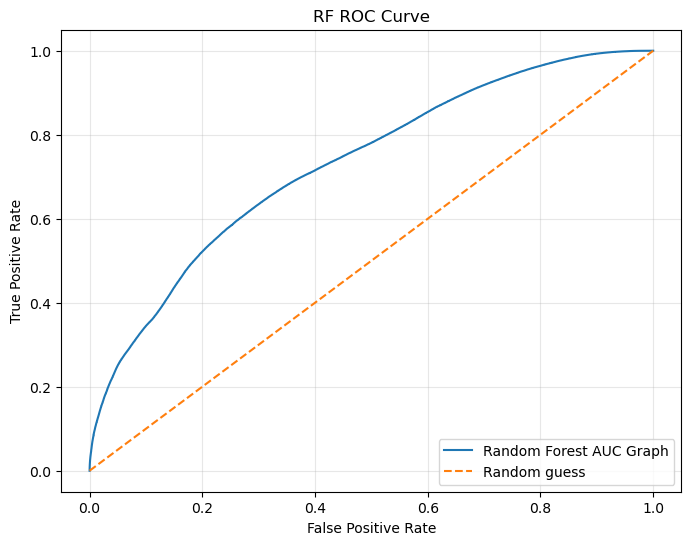

In [83]:
players_clean = pd.read_csv("players_cleaned.csv")
# Merge players with the shots they took. 
both_df = shots_df.merge(players_clean[['normalized_name', 'player_height', 
'player_weight']],left_on="PLAYER_NAME",right_on="normalized_name",
how="left")
def height_group(h):
    return "Short" if h < 190 else ("Medium" if h <= 205 else "Tall")
# Add more supporting variables relevant to NBA shot complexity 
both_df["HEIGHT_GROUP"] = both_df["player_height"].apply(height_group)
model_df = both_df.copy()
model_df["SHOT_MADE"] = model_df["SHOT_MADE"].astype(int)
model_df["ANGLE"] = np.degrees(np.arctan2(model_df["LOC_X"], 
model_df["LOC_Y"]))
model_df["ABS_X"] = model_df["LOC_X"].abs()
model_df["ABS_Y"] = model_df["LOC_Y"].abs()
model_df["DIST_X_HEIGHT"] = (model_df["SHOT_DISTANCE"] 
* model_df["player_height"])
model_df["DIST_X_WEIGHT"] = (model_df["SHOT_DISTANCE"] 
* model_df["player_weight"])
def classify_2pt_3pt(distance):
    return "3PT" if distance > 23.75 else "2PT"
model_df["SHOT_ZONE_CLASS"] = (
model_df["SHOT_DISTANCE"].apply(classify_2pt_3pt))
category_cols = ["TEAM_NAME", "ZONE_NAME", "SHOT_TYPE", 
"HEIGHT_GROUP", "SHOT_ZONE_CLASS"]

# Apply one-hot encoding on the textual category columns 
x_cat_hot = pd.get_dummies(model_df[category_cols], prefix=category_cols)
number_cols = ["SHOT_DISTANCE","player_height","player_weight","ANGLE",
"ABS_X","ABS_Y","DIST_X_HEIGHT","DIST_X_WEIGHT",]
if "TOTAL_SECS_LEFT" in model_df.columns:
   number_cols.append("TOTAL_SECS_LEFT")
x_numbers = model_df[number_cols]
combined_x = pd.concat([x_cat_hot, x_numbers], axis=1)
shot_made_y = model_df["SHOT_MADE"]
X_train, X_test, y_train, y_test = train_test_split(combined_x,
shot_made_y,test_size=0.2,random_state=42,stratify=shot_made_y)
# Train the dataset using 80% of the data from the one-hot encoded matrix.
rand_forest = RandomForestClassifier(n_estimators=100,random_state=42,
max_depth=15,n_jobs=-1)
rand_forest.fit(X_train, y_train)
y_pred = rand_forest.predict(X_test)
# Get the accuracies of both models.
forest_accuracy = accuracy_score(y_test, y_pred)
all_misses_accuracy = 1 - y_test.mean()
print("Classification Report:")
print(classification_report(y_test, y_pred, digits=3))
print(f"Predict all misses accuracy: {all_misses_accuracy:.3f}")
print(f"Random Forest accuracy: {forest_accuracy:.3f}")
y_probability = rand_forest.predict_proba(X_test)[:, 1]
false_pos, true_pos, t = roc_curve(y_test, y_probability)
auc_for_roc = auc(false_pos, true_pos)
print(f"Area Under the Curve: {auc_for_roc:.3f}")
plt.figure(figsize=(8, 6))
plt.ylabel("True Positive Rate")
plt.xlabel("False Positive Rate")
plt.plot(false_pos, true_pos, label=f"Random Forest AUC Graph")
# Plot with the random being dotted.
plt.plot([0, 1], [0, 1], linestyle='--', label="Random guess")
plt.title("RF ROC Curve")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()


Our evaluation showed the Random Forest outperformed the baseline model. Predicting every shot as a miss yields an accuracy of 0.519. In contrast, the Random Forest reached an accuracy of 0.650 which demonstrates a substantial improvement in identifying make/miss outcomes. The classification report showed that the model performs very well on missed shots (recall 0.853). Meaning it correctly identifies most misses, while shots show higher precision (0.730) but lower recall (0.430), indicating the model is more selective when prediction a make. The F1 scores (0.717 for misses, 0.541 for makes) reflect this imbalance, as made shots are inherently harder to predict. Both macro and weighted averages (F1  0.63) show the model maintains a stable performance across classes despite the uneven distribution. The ROC-AUC score of 0.730  demonstrates the model is effective at separating high and low quality shot attempts across probability tresholds.

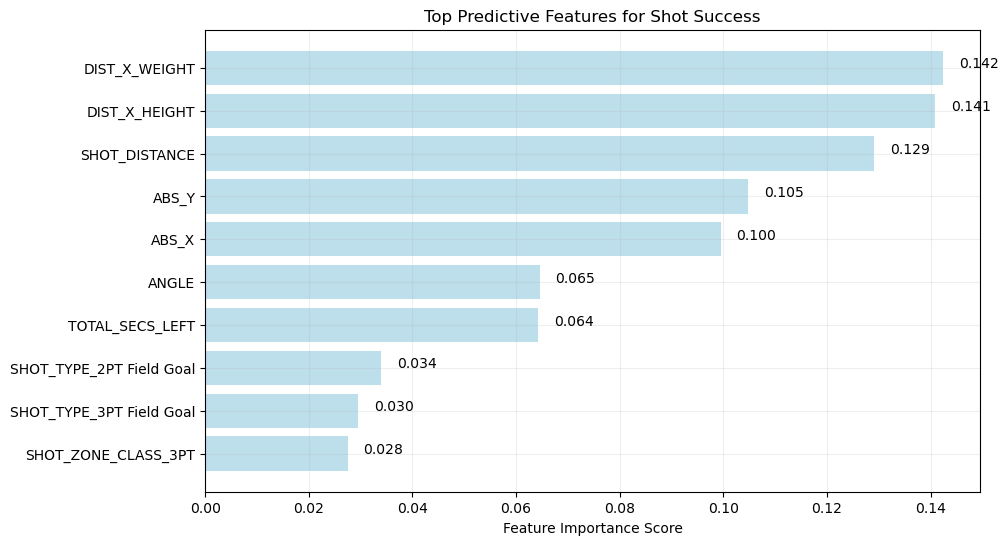

In [84]:
# Feature Importance Analysis and Plot
# Calculate feature importance
important_features = pd.DataFrame({'feature': combined_x.columns, 
'importance': rand_forest.feature_importances_}
).sort_values('importance', ascending=False)
# Create plot.
plt.figure(figsize=(10, 6))
# Get the top 10 most important.
most_important = important_features.head(10)
# Make a horizontal bar plot.
bars = plt.barh(range(len(most_important)), 
most_important['importance'].values, color='lightblue', alpha=0.8)
plt.yticks(range(len(most_important)), 
most_important['feature'].tolist())
plt.xlabel('Feature Importance Score')
plt.title('Top Predictive Features for Shot Success')
# Invert the y-axis for easy viewing.
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.2)
for index, bar_val in enumerate(most_important['importance'].values):
    # Format the numbers over the bars..
    plt.text(bar_val + 0.003, index, f'{bar_val:.3f}')
plt.show()


The top predictive features show that the interactions terms of DIST_X_WEIGHT and DIST_X_HEIGHT are the strongest predictors of shot success. This indicates that the relationship between shooting distance and a player's physical build plays a key role in shot success probability. SHOT_DISTANCE itself is the next most influential variable which reinforces how strongly raw distance drives make probability.
Spatial geometry features also rank highly: ABS_Y, ABS_X, and ANGLE collectively suggest the model learned that certain court locations, such as straight-on shots or middle-floor attempts tend to produce higher success rates, while sharper angles and deep corner positions introduce more difficulty. 
Next, TOTAL_SECS_LEFT shows that timing influences efficiency, likely reflecting low-time clock heaves or rushed attempts.

---

### Visualization: 

We expected different NBA teams to be the most efficient shooters in different court zones. To test this, we calculated shooting percentages by team and zone and identified the top performers. Our results showed the Lakers dominated the paint, the Clippers were strongest on the right side, the Suns led on the left wing, and the Wizards took the most long-distance desperation shots. This supports the idea that each team has zone-specific strengths that reflect its offensive style.

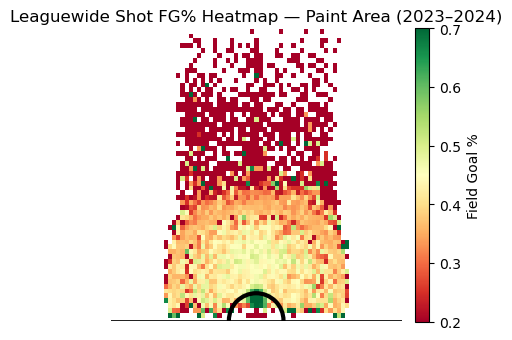

In [85]:
df_23_24 = shots_df[(shots_df['SEASON_1'] >= 2023) & 
(shots_df['SEASON_1'] <= 2024)].copy()
if df_23_24['SHOT_MADE'].dtype != bool:
    df_23_24['SHOT_MADE'] = (df_23_24['SHOT_MADE'].astype(str).str.lower()
    .map({'true': True, 'false': False, '1': True, '0': False}))

heat_df = df_23_24[(df_23_24['LOC_X'].between(-80, 80)) & (
    (df_23_24['LOC_Y'].between(0, 190)))].copy()
heat = heat_df[['LOC_X','LOC_Y','SHOT_MADE']].dropna()

xbins = np.linspace(-80, 80, 140)
ybins = np.linspace(0, 190, 140)
xcat = pd.cut(heat['LOC_X'], bins=xbins, include_lowest=True)
ycat = pd.cut(heat['LOC_Y'], bins=ybins, include_lowest=True)
grid = (heat.assign(xbin=xcat, ybin=ycat).groupby(['xbin','ybin'], 
observed=False).agg(Total=('SHOT_MADE','size'), 
Made=('SHOT_MADE','sum')).reset_index())
grid['FG_Pct'] = grid['Made'] / grid['Total']

def mid(iv): 
    return np.nan if pd.isna(iv) else (iv.left + iv.right) / 2
grid['xc'] = grid['xbin'].apply(mid)
grid['yc'] = grid['ybin'].apply(mid)
pivot = grid.pivot_table(index='yc', columns='xc', values='FG_Pct', 
aggfunc='mean', observed=False)
arr = np.array(pivot)
extent = [pivot.columns.min(), pivot.columns.max(), 
pivot.index.min(), pivot.index.max()]
fig, ax = plt.subplots(figsize=(4, 5))
ax.add_patch(Rectangle((-80, 0), 160, 190, lw=1.2, 
fill=False, color='black'))
ax.add_patch(Rectangle((-60, 0), 120, 190, lw=1.0, 
fill=False, color='black'))
ax.add_patch(Circle((0, 0), radius=7.5, lw=3, 
fill=False, color='black'))
im = ax.imshow(arr, extent=extent, origin='lower', 
vmin=0.2, vmax=0.7, cmap='RdYlGn')
ax.set_xlim(-40, 40)
ax.set_ylim(0, 80)
ax.set_aspect('equal', adjustable='box')
ax.axis('off')
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Field Goal %')
ax.set_title("Leaguewide Shot FG% Heatmap — Paint Area (2023–2024)")
plt.tight_layout()
plt.show()


This heatmap shows leaguewide field goal percentage in the paint during the 2023–2024 seasons. Each square represents a small court region, with colors showing how efficiently players score there. Areas closest to the rim appear in green and yellow, reflecting the highest shooting percentages (around 60–70%). This makes sense since layups and dunks are the most efficient shots in basketball.

---

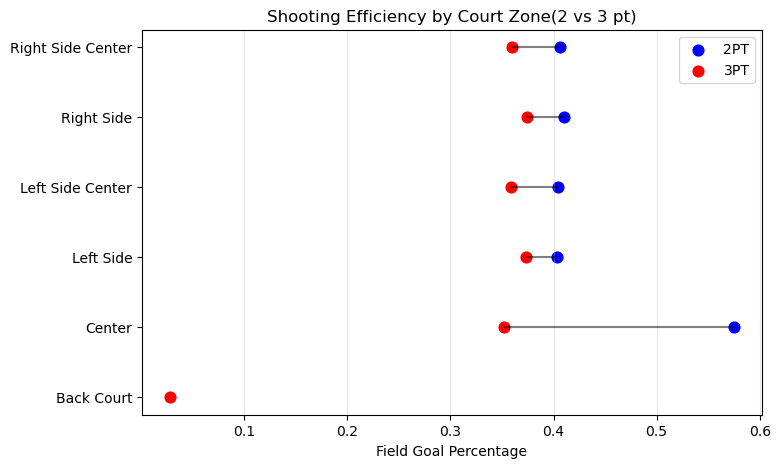

In [86]:
# Zone Efficiency Plot
# Calculate zone efficiency statistics.
zone_efficiency = zone_analysis_df.groupby(['ZONE_NAME', 
'SHOT_ZONE_CLASS']).agg({'SHOT_MADE': ['count', 'mean']}).round(4)
zone_efficiency.columns = ['Total_Shots', 'FG_Pct']
zone_efficiency = zone_efficiency.sort_values('FG_Pct', ascending=False)
data_pivoted = zone_efficiency.reset_index().pivot(index='ZONE_NAME', 
columns='SHOT_ZONE_CLASS', values='FG_Pct')
zones = data_pivoted.index
two_point_xval = data_pivoted['2PT']
three_point_xval = data_pivoted['3PT']
plt.figure(figsize=(8, 5))
y_pos = np.arange(len(zones))
plt.scatter(two_point_xval, y_pos, color='blue', label='2PT', s=60)
plt.scatter(three_point_xval, y_pos, color='red', label='3PT', s=60)
for i in range(len(zones)):
    plt.plot([two_point_xval.iloc[i], three_point_xval.iloc[i]], 
    [y_pos[i], y_pos[i]], color='black', alpha=0.5)
plt.yticks(y_pos, zones)
plt.xlabel("Field Goal Percentage")
plt.title("Shooting Efficiency by Court Zone(2 vs 3 pt)")
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.show()


### Additional work: 

Top Teams with 95% Confidence Intervals:


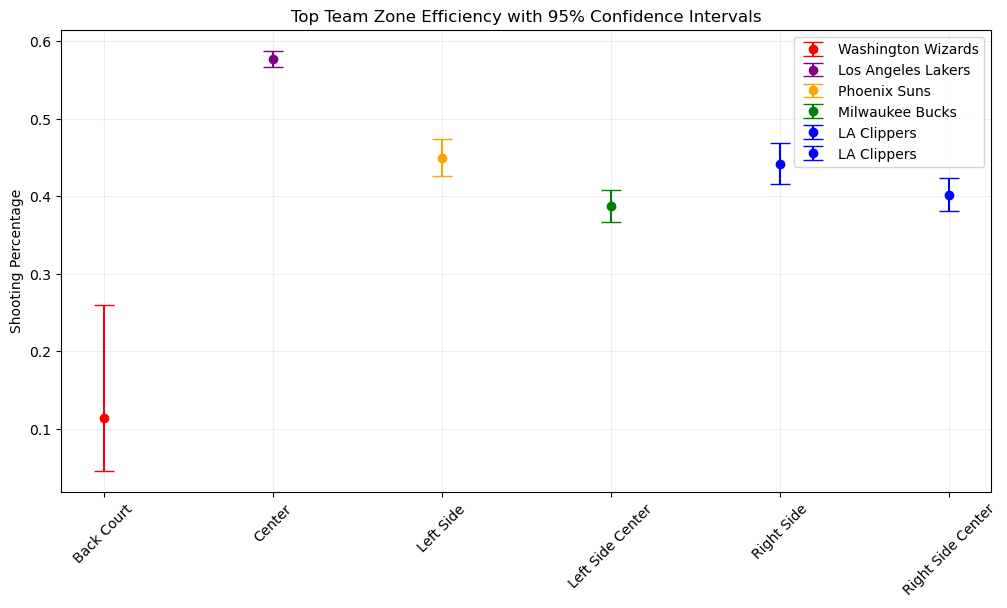

In [87]:
# Compute team/zone shooting stats
zone_stats = (zone_analysis_df.groupby(["TEAM_NAME", "ZONE_NAME"])
.agg(Total_Shots=("SHOT_MADE", "size"),Shots_Made=("SHOT_MADE", "sum"))
.reset_index())
zone_stats["Shooting_Percent"] = zone_stats["Shots_Made"] / (
    zone_stats["Total_Shots"])
# For each zone, keep  the top team by shooting percentage..
top_teams_df = (zone_stats.sort_values(["ZONE_NAME", "Shooting_Percent"], 
ascending=[True, False]).groupby("ZONE_NAME")
.head(1).reset_index(drop=True))
# Statistical Significance Analysis With Plot
def calculate_CI(made, total):
    # Calculated z score.
    z_stat = stats.norm.ppf(1 - (1 - .95) / 2)
    # Calculate the probability of making a shot.
    prob = made / total
    denominator = 1 + z_stat**2 / total
    # Center adjust the probabiltiy.
    prob_adjusted = prob + z_stat**2 / (2 * total)
    # Find the standard deviation
    adjusted_SD = np.sqrt((prob * (1 - prob) + z_stat**2 / (
        (4 * total))) / total)
    # FInd the upper and lower bounds of the interval.
    lower_bound = (prob_adjusted - z_stat * adjusted_SD) / denominator
    upper_bound = (prob_adjusted + z_stat * adjusted_SD) / denominator
    return lower_bound, upper_bound

print("Top Teams with 95% Confidence Intervals:")
plt.figure(figsize=(12, 6))
colors = ['red', 'purple', 'orange', 'green', 'blue', 'blue']

for i, (zone_index, zone_row_data) in enumerate(top_teams_df.iterrows()):
    # Calculate the lower and upper bounds.
    lowerCI, upperCI = calculate_CI(zone_row_data['Shots_Made'], 
    zone_row_data['Total_Shots'])
    top_teams_df.loc[zone_index, 'CI_Lower'] = lowerCI
    top_teams_df.loc[zone_index, 'CI_Upper'] = upperCI
    # Create the error bars with the confidence intervals found 
    # above and soe specifications.
    plt.errorbar(x=i, y=zone_row_data['Shooting_Percent'], 
    yerr=[[zone_row_data['Shooting_Percent'] - lowerCI], 
    [upperCI - zone_row_data['Shooting_Percent']]],
    fmt='o', capsize=7, color=colors[i], 
    label=f"{zone_row_data['TEAM_NAME']}")

# Show the plot.
plt.xticks(range(len(top_teams_df)), top_teams_df['ZONE_NAME'], 
rotation=45)
plt.ylabel('Shooting Percentage')
plt.title('Top Team Zone Efficiency with 95% Confidence Intervals')
plt.grid(True, alpha=0.2)
plt.legend(loc='upper right')
plt.show()

---

### Results: 
We started with two NBA shot datasets totaling 435,921 attempts across two seasons. After combining them, we simplified the data by removing redundant columns, including EVENT_TYPE, which was fully aligned with SHOT_MADE. We also checked for missing values and found none. To keep our analysis focused, we created a condensed dataframe with six key features: TEAM_NAME, SHOT_TYPE, BASIC_ZONE, ZONE_NAME, SHOT_ZONE_CLASS, and SHOT_MADE. For our height analysis, we brought in a second dataset with player information, cleaned it to keep only players from the 2023–2024 seasons, and merged height and weight into the shot dataset. This let us compare shooting efficiency across court zones by different height groups.

We engineered several features to improve our spatial analysis. The main one was classifying shots as 2-pointers or 3-pointers using the NBA’s official 23.75-foot line. We also calculated 95% confidence intervals for zone shooting percentages to ensure our comparisons were statistically reliable given different sample sizes across court areas.

We first verified that both seasons had nearly identical overall field goal percentages (47.54% for 2023 and 47.43% for 2024). Using confidence intervals, we confirmed that efficiency differences across zones and teams were statistically meaningful, such as the Lakers’ strong center performance and the Clippers’ right-side shooting. Small-sample zones, like the Wizards’ back court attempts, showed very wide intervals. We then compared 2-point and 3-point efficiency by zone. Across every court zone, 2-pointers were more efficient (40%–57%) than 3-pointers (2%–37%), with the largest advantage in the center. Interestingly, 3-point efficiency stayed very consistent across angles, while 2-point efficiency varied more, showing how positioning affects closer-range shots.

After grouping players as Short, Medium, or Tall, we saw clear efficiency differences. Tall players had the highest field goal percentages because they score most near the rim, medium players were steady across zones, and short players struggled in the paint but showed slightly better accuracy on the perimeter. A scatter plot by height and court zone confirmed these patterns, especially tall players’ dominance in the center zone.


### Takeaways
Our analysis revealed several important patterns about NBA shooting efficiency across the 2023 and 2024 regular seasons. First we found that certain court zones consistently produce higher scoring efficiency, with the center zone being the most reliable for all teams. Incorporating player height into our analysis showed us that tall players dominated the center zone with the highest field-goal percentages, medium height players showed a balanced performance across all zones while short players relied heavily on the perimeter areas. These patterns demonstrate how physical attributes like height influence directly where players choose to take their shot and how effectively they are able to score.

---

### Appendix: 

CJ focused on the data acquisition and cleaning portion of our project. He made sure the dataset was complete, properly formatted, and ready to use by handling missing values, organizing columns, and documenting the preprocessing steps. His work gave us a clean foundation to build everything else on. Siri handled most of the exploratory data analysis and visualizations. She created shot charts, heatmaps, and other graphics that helped us quickly understand shooting patterns and trends in the dataset. Her visual work guided the direction of our deeper analysis. Riya led the statistical modeling side of the project. She built and evaluated the random forest model to identify which factors had the biggest impact on shot success. She also helped interpret the model results and explain them in a way that made sense in the context of NBA gameplay. Bryce took charge of the technical setup and code organization. He structured our notebooks, wrote helper functions, and kept the GitHub repository organized so everyone could work smoothly. His work made the entire workflow more efficient and easier to follow. Vitaliy contributed to both the analytical and writing components of the project. He helped refine and evaluate the machine learning model by assisting with feature selection, testing different configurations, and interpreting the model outputs in the context of NBA shot efficiency. He also made a draft of the final report, putting everyone’s work together and making sure the explanations, visuals, and results were clear and consistent.